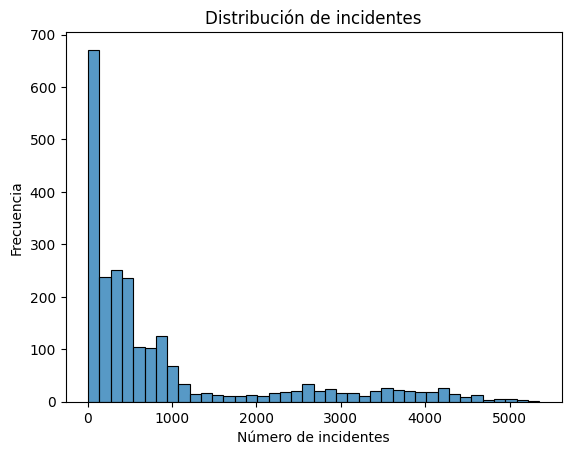

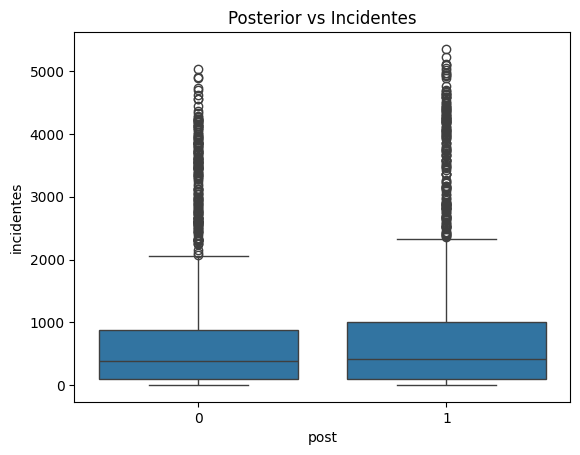

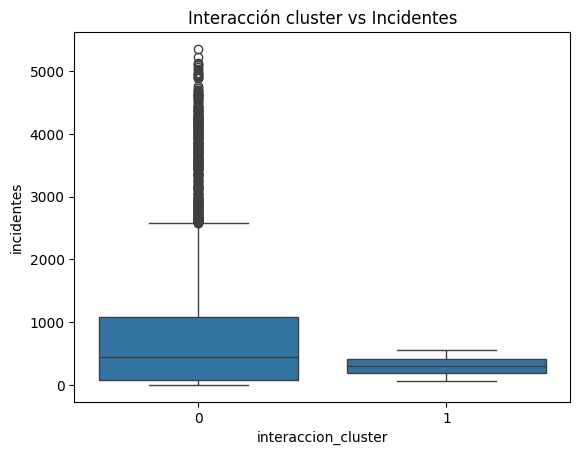

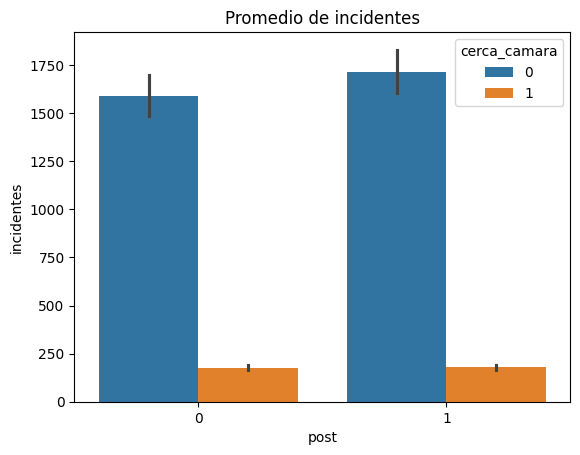

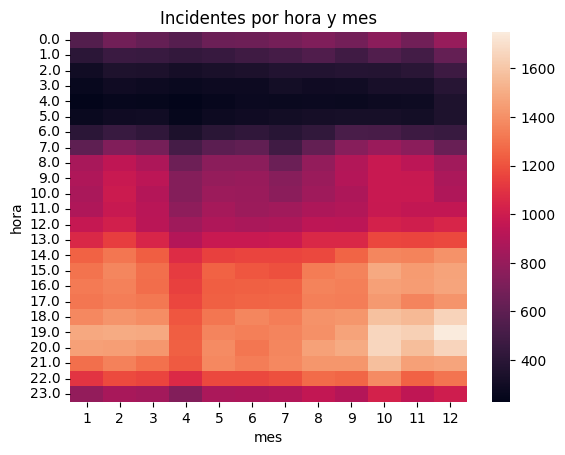

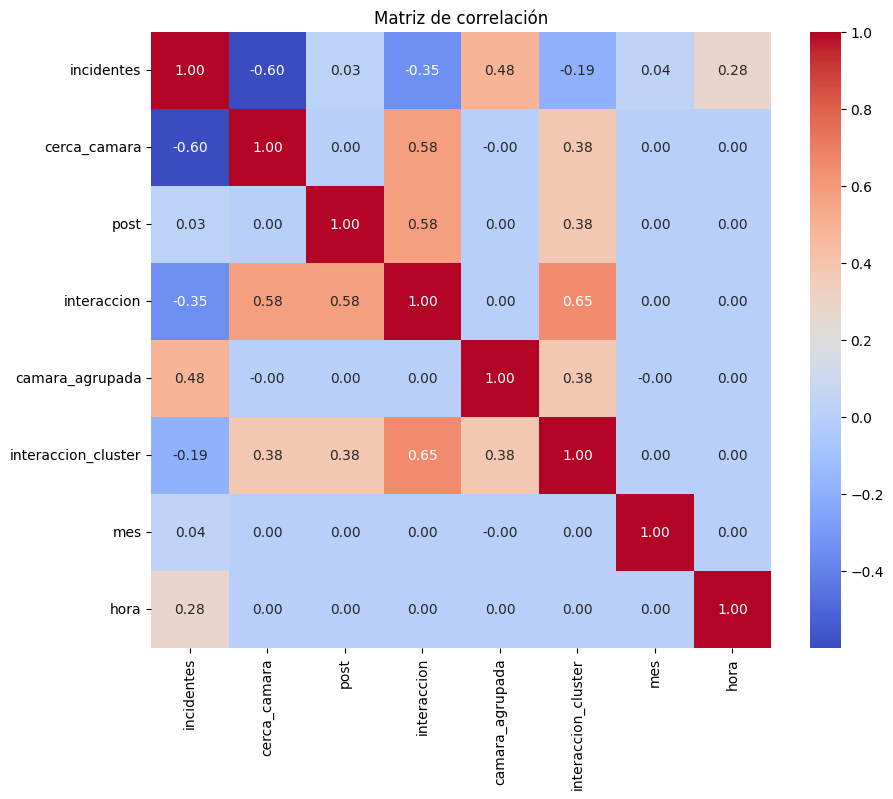


RESUMEN DE LOS MODELOS: 
                            OLS Regression Results                            
Dep. Variable:             incidentes   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     646.7
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        18:40:22   Log-Likelihood:                -14566.
No. Observations:                1843   AIC:                         2.915e+04
Df Residuals:                    1835   BIC:                         2.919e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const   

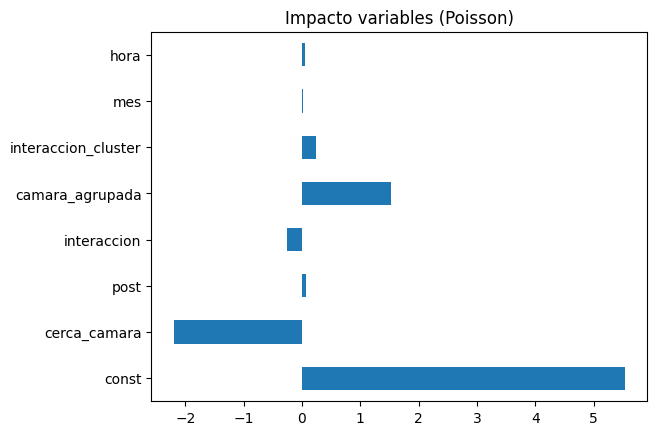

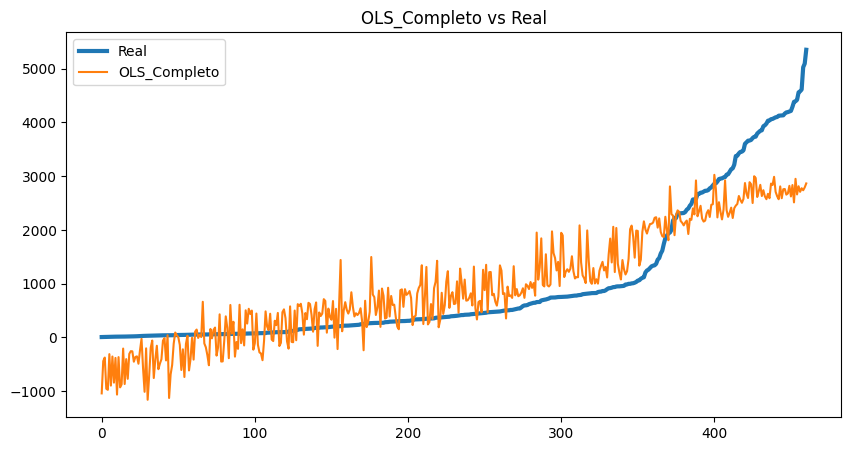

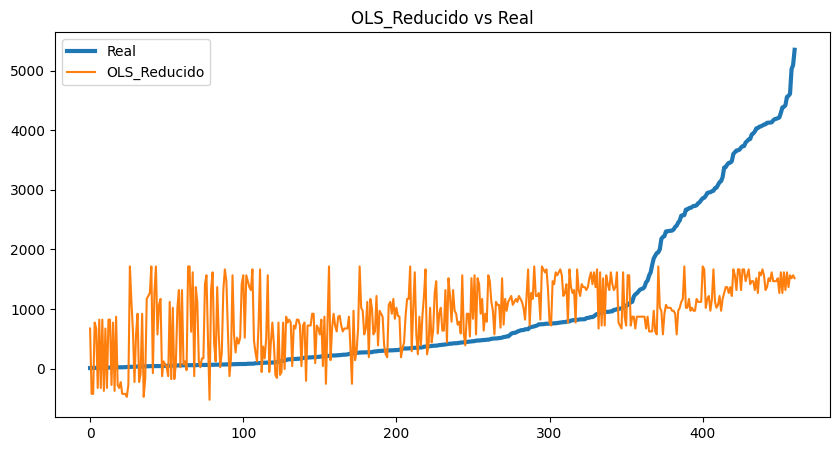

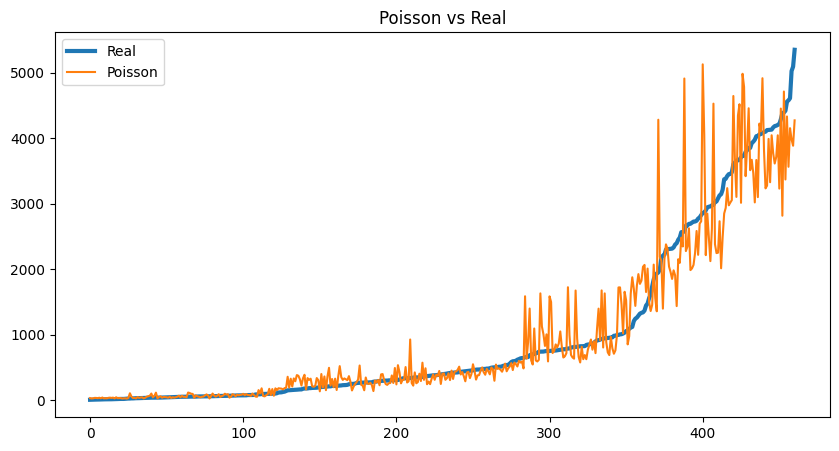

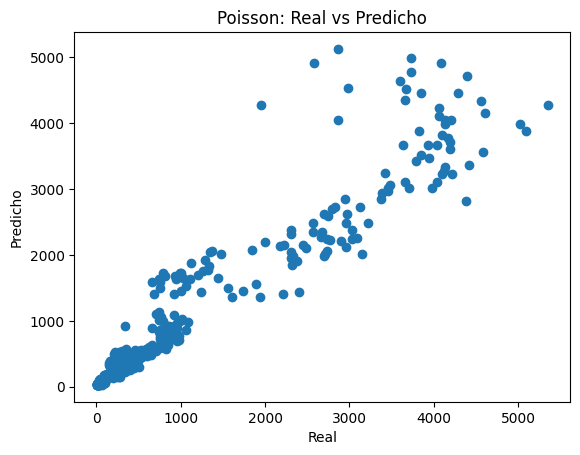

In [3]:
# TITULO: MODELO PARA LA EVALUACIÓN DE FOTOMULTAS EN CDMX
# AUTOR: EDUARDO HERNANDEZ MARTINEZ
# FECHA DE ULTIMA MODIFICACION: 01/05/2026
#----------------------------------------------- DECLARACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.spatial import cKDTree
import unicodedata

#----------------------------------------------- DECLARACIÓN DE FUNCIONES

# Función que estandariza el texto
def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto.lower().strip()
# Función para normalizar las vialidades quitando información extra
def normalizar_via(texto):
    texto = limpiar_texto(texto)

    if "circuito bicentenario" in texto:
        return "circuito bicentenario"
    elif "periferico" in texto:
        return "periferico"
    elif "viaducto" in texto:
        return "viaducto"
    elif "insurgentes" in texto:
        return "insurgentes"
    elif "reforma" in texto:
        return "reforma"
    elif "ignacio zaragoza" in texto:
        return "ignacio zaragoza"
    direcciones = ["norte", "sur", "oriente"]
    for i in range(1, 9):
        for d in direcciones:
            eje = f"eje {i} {d}"
            if eje in texto:
                return eje

    return "otra"

#----------------------------------- CARGA DE LOS DATOS

fotomultas = pd.read_csv('fotomultas_preliminar.csv')
accidentes = pd.read_csv('incidentes_limpio.csv')

#-------------------------------------- PREPARACIÓN DE LOS DATOS

accidentes['categoria'] = accidentes['categoria'].str.strip().str.lower()
accidentes = accidentes[accidentes['categoria'].isin(['accidente', 'lesionado', 'cadáver', 'cadaver'])]
accidentes['fecha'] = pd.to_datetime(accidentes['fecha'])
accidentes['mes'] = accidentes['fecha'].dt.month
accidentes['hora'] =  (accidentes['hora'].astype(str).str.extract(r'(\d{1,2})')[0].astype(float))
fotomultas['via_limpia'] = fotomultas['via_princi'].apply(normalizar_via)

#------------------------------------- CREACIÓN DE VARIABLES PARA EL MODELO

accident = accidentes[['latitud','longitud']].copy()
camar = fotomultas[['latitud','longitud']].copy() #Copiamos las coordenadas de los accidentes y las camaras
acc_coords = np.radians(accident)
cam_coords = np.radians(camar) #Convertimos esas coordenadas a radianes para con ello poder hacer mediciones

arbol = cKDTree(cam_coords) #Creamos un arbol para ordenar las coordenadas y con ello eficientizar la busqueda de cámaras cercanas a un accidente
radio_km = 0.3 #Definimos 300 metros como parametro de cercanía
radio_rad = radio_km / 6371 #lo convertimos a radianes dividiendolo entre le diametro de la tierra

indices = arbol.query_ball_point(acc_coords, r=radio_rad) #La funcion query_ball_point te otorga una lista de listas de los indices de las camaras cercanas al accidente

accidentes['cerca_camara'] = 0
accidentes.loc[accident.index, 'cerca_camara'] = [1 if len(i) > 0 else 0 for i in indices] # Después de definir todas en 0, cambia a 1 aquellos accidentes que tuvieron al menos 1 cámara cerca
conteo_vias = fotomultas['via_limpia'].value_counts()
vias_grandes = conteo_vias[conteo_vias > 3].index #Si la vialidad tuvo al menos 4 cámaras es considerada como una vialidad grande

fotomultas['camara_agrupada'] = fotomultas['via_limpia'].isin(vias_grandes).astype(int) #Establece a cada camara una variable binaria de si está agrupada o no

dist, indi = arbol.query(acc_coords)  #La funcion query te da la distancia y el indice de la camara más cercana
fotomultas = fotomultas.reset_index(drop=True)

accidentes['camara_indi'] = -1
accidentes.loc[accident.index, 'camara_indi'] = indi #Le asignamos a cada accidente el indice de la cámara más cercana

accidentes['camara_agrupada'] = accidentes['camara_indi'].apply(lambda i: fotomultas.loc[int(i), 'camara_agrupada'] if i >= 0 and i < len(fotomultas) else 0) #se crea una variable binaria de camara agrupada en accidentes

#--------------------------------------------- DID

fecha_inicio = pd.to_datetime("2019-01-01") #Fecha de consolidación de las fotomultas
#Se empiezan a crear variables espaciales y temporales con los datos otorgados
accidentes['post'] = (accidentes['fecha'] >= fecha_inicio).astype(int)
accidentes['interaccion'] = accidentes['cerca_camara'] * accidentes['post']
accidentes['interaccion_cluster'] = (accidentes['cerca_camara'] *accidentes['post'] *accidentes['camara_agrupada'])

#------------------------------------- AGRUPACIÓN

df = accidentes.groupby(['mes','hora','cerca_camara','post','interaccion','camara_agrupada','interaccion_cluster']).size().reset_index(name='incidentes')

#----------------------------------------------GRAFICA DE DISTRIBUCIÓN DE INCIDENTES

plt.figure()
sns.histplot(df['incidentes'], bins=40)
plt.title("Distribución de incidentes")
plt.xlabel("Número de incidentes")
plt.ylabel("Frecuencia")
plt.show()

#--------------------------------------------ANÁLISIS DE DATOS EXPLORATORIO
#Gráfica de caja comparando los incidentes antes y después de las fotomultas
plt.figure()
sns.boxplot(x='post', y='incidentes', data=df)
plt.title("Posterior vs Incidentes")
plt.show()
#Gráfica de caja comparando los incidentes afectados por una camara agrupada y los que no
plt.figure()
sns.boxplot(x='interaccion_cluster', y='incidentes', data=df)
plt.title("Interacción cluster vs Incidentes")
plt.show()
#Gráfica de barras de los promedios de incidentes antes y después de las camaras
plt.figure()
sns.barplot(x='post', y='incidentes', hue='cerca_camara', data=df)
plt.title("Promedio de incidentes")
plt.show()
#Mapa de calor de la incidencia de accidentes por mes y hora
pivot = df.pivot_table(values='incidentes', index='hora', columns='mes')
plt.figure()
sns.heatmap(pivot)
plt.title("Incidentes por hora y mes")
plt.show()


#---------------------------------------------- GRAFICA DE CORRELACIÓN

corr = df[['incidentes','cerca_camara','post','interaccion','camara_agrupada','interaccion_cluster','mes','hora']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

#-------------------------------------ENTRENAMIENTO

X = df[['cerca_camara','post','interaccion','camara_agrupada','interaccion_cluster','mes','hora']]
y = df['incidentes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#------------------------------------------ MODELOS

mod1 = sm.OLS(y_train, sm.add_constant(X_train)).fit()

mod2 = sm.OLS(y_train,sm.add_constant(X_train[['interaccion','interaccion_cluster','hora']])).fit()

mod3 = sm.GLM(y_train, sm.add_constant(X_train), family=sm.families.Poisson()).fit()

#--------------------------------- RESULTADOS DE LOS MODELOS

print("\nRESUMEN DE LOS MODELOS: ")
print(mod1.summary())
print(mod2.summary())
print(mod3.summary())

#------------------------------------ PREDICCIONES

pred1 = mod1.predict(sm.add_constant(X_test))
pred2 = mod2.predict(sm.add_constant(X_test[['interaccion','interaccion_cluster','hora']]))
pred3 = mod3.predict(sm.add_constant(X_test))

#------------------------------------ MÉTRICAS

rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))

print("\nMÉTRICAS:")
print("\nRMSE:")
print("OLS Completo:", rmse1)
print("OLS Reducido:", rmse2)
print("Poisson:", rmse3)

print("\nAIC:")
print("OLS Completo:", mod1.aic)
print("OLS Reducido:", mod2.aic)
print("Poisson:", mod3.aic)

print("\n")
print("Media de inciddentes",df['incidentes'].mean())
print("Varianza de incidentes",df['incidentes'].var())
print("\n")

#----------------------------------------------- COEFICIENTES POISSON

coef = pd.Series(mod3.params)
plt.figure()
coef.plot(kind='barh')
plt.title("Impacto variables (Poisson)")
plt.show()

#------------------------------------------------ COMPARACIÓN ENTRE LOS MODELOS

df_comp = pd.DataFrame({
    'Real': y_test.values,
    'OLS_Completo': pred1,
    'OLS_Reducido': pred2,
    'Poisson': pred3
}).sort_values(by='Real').reset_index(drop=True)

for col in ['OLS_Completo','OLS_Reducido','Poisson']:
    plt.figure(figsize=(10,5))
    plt.plot(df_comp['Real'], label='Real', linewidth=3)
    plt.plot(df_comp[col], label=col)
    plt.title(f"{col} vs Real")
    plt.legend()
    plt.show()

#------------------------------------------------------ GRAFICA FINAL DEL MODELO ELEGIDO y=x

plt.figure()
plt.scatter(y_test, pred3)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Poisson: Real vs Predicho")
plt.show()



